# Análisis Exploratorio de Datos — Estrés Hídrico en Parcelas Aguacateras
## Avance 1: Análisis Exploratorio y Preprocesamiento

**Objetivo General:**  
Describir e integrar datos geoespaciales y espectrales de 100 parcelas aguacateras en Jalisco, caracterizar distribuciones,
identificar anomalías y preparar el dataset para modelado predictivo de estrés hídrico.

**Alcance:**
- Análisis de estructura de datos (formas, tipos, valores faltantes)
- Estadísticas descriptivas univariantes
- Análisis bi/multivariante de correlaciones
- Preprocesamiento (limpieza, normalización, manejo de outliers)
- Conclusiones y patrones identificados

**Fuentes de datos:**
- `aguacates_jalisco_5_5_26.kml` — 100 parcelas georreferenciadas
- `aguacates_jalisco_monthly_indices_2023_2026.csv` — 4 000 observaciones de índices espectrales mensuales

**Fecha:** Mayo 8, 2026

---
## 0. Configuración del Entorno

In [110]:
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from scipy.stats import skew, kurtosis, shapiro
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import rasterio
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid', palette='viridis')

BASE_DIR   = Path(os.getcwd())
KML_PATH   = BASE_DIR / "data/csv/aguacates_jalisco_5_5_26.kml"
CSV_PATH   = BASE_DIR / "data/csv/aguacates_jalisco_monthly_indices_2023_2026.csv"
GEOTIF_DIR = BASE_DIR / "data/geotiff"
OUT_PATH   = BASE_DIR / "data/csv/df_eda_processed.csv"

print('✓ Entorno configurado')

✓ Entorno configurado


---
## 1. Estructura de los Datos

In [84]:
def parse_kml_to_gdf(path: str) -> gpd.GeoDataFrame:
    tree = ET.parse(path)
    root = tree.getroot()
    ns = {'kml': 'http://www.opengis.net/kml/2.2'}
    records = []
    for pm in root.findall('.//kml:Placemark', ns):
        name = pm.find('kml:name', ns).text
        coords_raw = pm.find('.//kml:coordinates', ns).text.strip()
        lon, lat, alt = map(float, coords_raw.split(','))
        num = int(''.join(filter(str.isdigit, name)))
        records.append({
            'parcela': name, 'num': num, 'lon': lon, 'lat': lat,
            'altitud_kml': alt, 'geometry': Point(lon, lat)
        })
    gdf = gpd.GeoDataFrame(records, crs='EPSG:4326')
    return gdf.sort_values('num').reset_index(drop=True)

gdf = parse_kml_to_gdf(KML_PATH)
print(f'Forma KML: {gdf.shape}')
print('\n--- Tipos de datos (KML) ---')
print(gdf.dtypes)
print('\n--- Valores faltantes por columna (KML) ---')
print(gdf.isnull().sum())
display(gdf.head())

Forma KML: (100, 6)

--- Tipos de datos (KML) ---
parcela             str
num               int64
lon             float64
lat             float64
altitud_kml     float64
geometry       geometry
dtype: object

--- Valores faltantes por columna (KML) ---
parcela        0
num            0
lon            0
lat            0
altitud_kml    0
geometry       0
dtype: int64


,parcela,num,lon,lat,altitud_kml,geometry
0,H1,1,-103.487470,19.663164,0.0,POINT (-103.48747 19.66316)
1,H2,2,-103.491681,19.659585,0.0,POINT (-103.49168 19.65958)
2,H3,3,-103.495946,19.649232,0.0,POINT (-103.49595 19.64923)
3,H4,4,-103.493425,19.648928,0.0,POINT (-103.49342 19.64893)
4,H5,5,-103.490541,19.647687,0.0,POINT (-103.49054 19.64769)


### 1.2 Carga de Índices Espectrales

In [85]:
df = pd.read_csv(CSV_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['name', 'date']).reset_index(drop=True)

print(f'Forma CSV: {df.shape}')
print(f'Período  : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Parcelas únicas: {df["name"].nunique()}')
print('\n--- Tipos de datos ---')
print(df.dtypes)
print(f'Valores faltantes: {df.isnull().sum().sum()}')
display(df.head())

Forma CSV: (4000, 9)
Período  : 2023-01-01 → 2026-04-01
Parcelas únicas: 100

--- Tipos de datos ---
name                      str
lat                   float64
lon                   float64
year                    int64
month                   int64
date           datetime64[us]
image_count             int64
NDVI                  float64
NDMI                  float64
dtype: object
Valores faltantes: 0


,name,lat,lon,year,month,date,image_count,NDVI,NDMI
0,H1,19.663164,-103.48747,2023,1,2023-01-01,4,0.319492,-0.063829
1,H1,19.663164,-103.48747,2023,2,2023-02-01,6,0.240143,-0.107686
2,H1,19.663164,-103.48747,2023,3,2023-03-01,6,0.218621,-0.139270
3,H1,19.663164,-103.48747,2023,4,2023-04-01,6,0.194678,-0.141275
4,H1,19.663164,-103.48747,2023,5,2023-05-01,6,0.197294,-0.153916


### 1.3 Estadísticas Descriptivas

Se calculan estadísticas resumidas para todas las variables numéricas del dataset CSV.  
El sesgo (*skewness*) indica la asimetría de la distribución: valores positivos señalan cola derecha y negativos cola izquierda.

In [86]:
numeric_cols = ['lat', 'lon', 'NDVI', 'NDMI']
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
display(df[numeric_cols].describe().round(4))

print(f'\nNDVI: media={df["NDVI"].mean():.4f}, sesgo={skew(df["NDVI"]):.4f}')
print(f'NDMI: media={df["NDMI"].mean():.4f}, sesgo={skew(df["NDMI"]):.4f}')

=== ESTADÍSTICAS DESCRIPTIVAS ===


,lat,lon,NDVI,NDMI
count,4000.0000,4000.0000,4000.0000,4000.0000
mean,19.6235,-103.4952,0.5085,0.0572
std,0.0141,0.0170,0.1383,0.1184
min,19.6021,-103.5269,0.0404,-0.2626
25%,19.6127,-103.5092,0.4023,-0.0296
50%,19.6211,-103.4935,0.5161,0.0657
75%,19.6339,-103.4856,0.6131,0.1461
max,19.6632,-103.4601,0.8664,0.3765



NDVI: media=0.5085, sesgo=-0.1558
NDMI: media=0.0572, sesgo=-0.1629


### 1.4 Cardinalidad y frecuencia de variables
La variable categórica principal es **`name`**, que identifica 100 parcelas (H1–H100).
Las variables temporales `year` y `month` permiten analizar la dimensión temporal.
En esta sección calculamos la cardinalidad de cada variable y exploramos la distribución de observaciones por parcela, año y mes.


In [87]:
print('=== CARDINALIDAD Y FRECUENCIA ===')
for col in df.columns:
    n = df[col].nunique()
    print(f'  {col:15s}  {n} valores únicos')

print('\nFrecuencia de parcelas (top 5):')
print(df['name'].value_counts().head())

# Distribución de años y meses
print('\nObservaciones por año:')
display(df['year'].value_counts().sort_index())

print('\nObservaciones por mes (1=enero … 12=diciembre):')
display(df['month'].value_counts().sort_index())


=== CARDINALIDAD Y FRECUENCIA ===
  name             100 valores únicos
  lat              100 valores únicos
  lon              100 valores únicos
  year             4 valores únicos
  month            12 valores únicos
  date             40 valores únicos
  image_count      8 valores únicos
  NDVI             4000 valores únicos
  NDMI             4000 valores únicos

Frecuencia de parcelas (top 5):
name
H1      40
H10     40
H100    40
H11     40
H12     40
Name: count, dtype: int64

Observaciones por año:


year
2023    1200
2024    1200
2025    1200
2026     400
Name: count, dtype: int64


Observaciones por mes (1=enero … 12=diciembre):


month
1     400
2     400
3     400
4     400
5     300
6     300
7     300
8     300
9     300
10    300
11    300
12    300
Name: count, dtype: int64

---
## 2. Análisis Univariante

Se emplea histograma + boxplot para las variables continuas (NDVI, NDMI, image_count),
gráfico de barras para las variables temporales discretas (mes, año),
y un scatter geoespacial para las coordenadas de las parcelas.


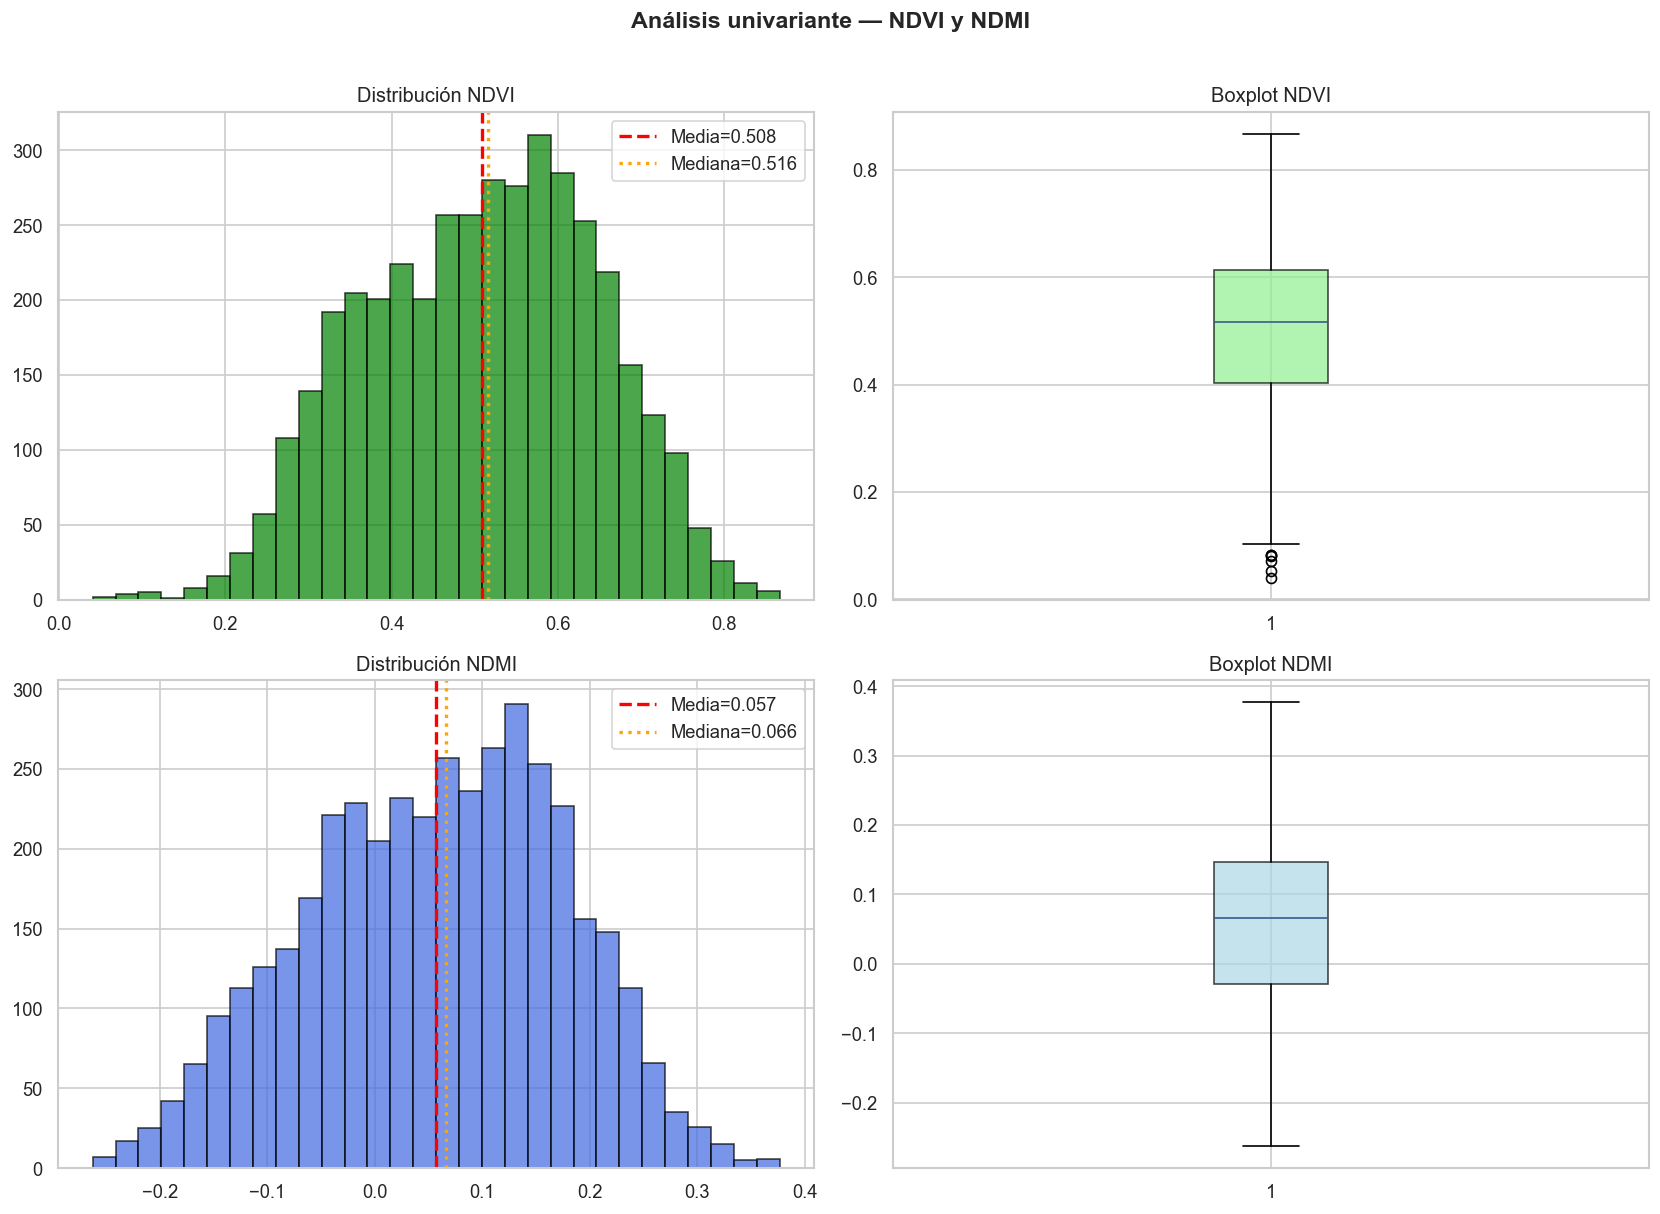

✓ Distribuciones visualizadas


In [88]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['NDVI'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(df['NDVI'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media={df["NDVI"].mean():.3f}')
axes[0, 0].axvline(df['NDVI'].median(), color='orange', linestyle=':', linewidth=2, label=f'Mediana={df["NDVI"].median():.3f}')
axes[0, 0].set_title('Distribución NDVI')
axes[0, 0].legend()

axes[0, 1].boxplot(df['NDVI'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightgreen', alpha=0.7))
axes[0, 1].set_title('Boxplot NDVI')

axes[1, 0].hist(df['NDMI'], bins=30, color='royalblue', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(df['NDMI'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media={df["NDMI"].mean():.3f}')
axes[1, 0].axvline(df['NDMI'].median(), color='orange', linestyle=':', linewidth=2, label=f'Mediana={df["NDMI"].median():.3f}')
axes[1, 0].set_title('Distribución NDMI')
axes[1, 0].legend()

axes[1, 1].boxplot(df['NDMI'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1, 1].set_title('Boxplot NDMI')

plt.suptitle('Análisis univariante — NDVI y NDMI', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('✓ Distribuciones visualizadas')

### 2.1 Calidad del composite: distribución espacial de `image_count`

image_count — min=1, max=9, media=5.08, mediana=5.0
Obs. con image_count == 1: 200 (5.0%) — menor confianza espectral


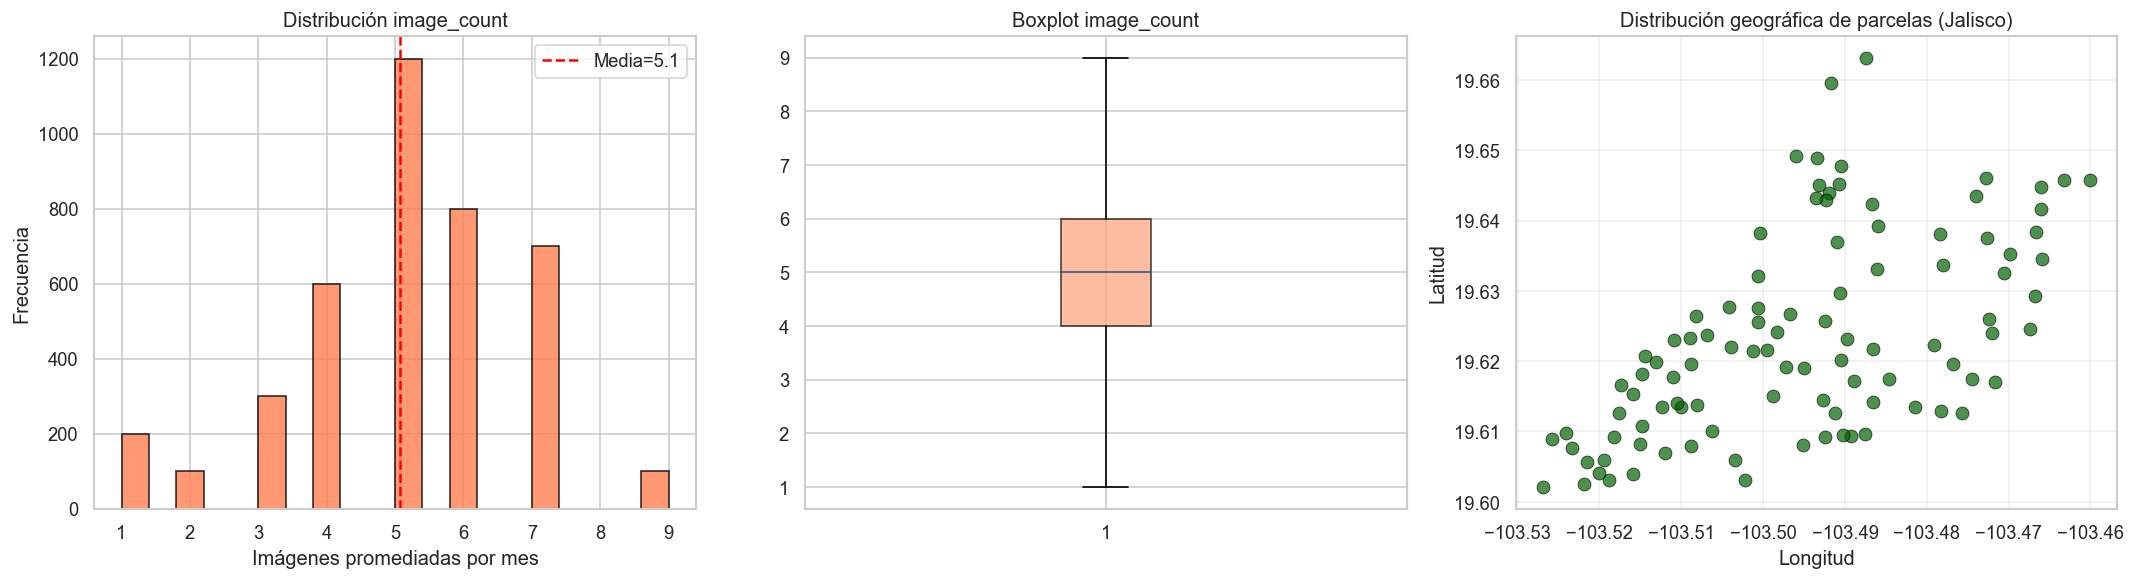

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma image_count
axes[0].hist(df['image_count'], bins=20, color='coral', alpha=0.8, edgecolor='black')
axes[0].set_title('Distribución image_count')
axes[0].set_xlabel('Imágenes promediadas por mes')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['image_count'].mean(), color='red', linestyle='--',
                label=f'Media={df["image_count"].mean():.1f}')
axes[0].legend()

# Boxplot image_count
axes[1].boxplot(df['image_count'], patch_artist=True,
                boxprops=dict(facecolor='lightsalmon', alpha=0.7))
axes[1].set_title('Boxplot image_count')

# Distribución geográfica de las 100 parcelas
axes[2].scatter(gdf['lon'], gdf['lat'], c='darkgreen', alpha=0.7, s=60, edgecolor='black', linewidth=0.5)
axes[2].set_xlabel('Longitud')
axes[2].set_ylabel('Latitud')
axes[2].set_title('Distribución geográfica de parcelas (Jalisco)')
axes[2].grid(alpha=0.3)

print(f'image_count — min={df["image_count"].min()}, max={df["image_count"].max()}, '
      f'media={df["image_count"].mean():.2f}, mediana={df["image_count"].median()}')
print(f'Obs. con image_count == 1: {(df["image_count"]==1).sum()} '
      f'({(df["image_count"]==1).mean()*100:.1f}%) — menor confianza espectral')
plt.tight_layout()
plt.show()


### 2.2 Distribución Temporal

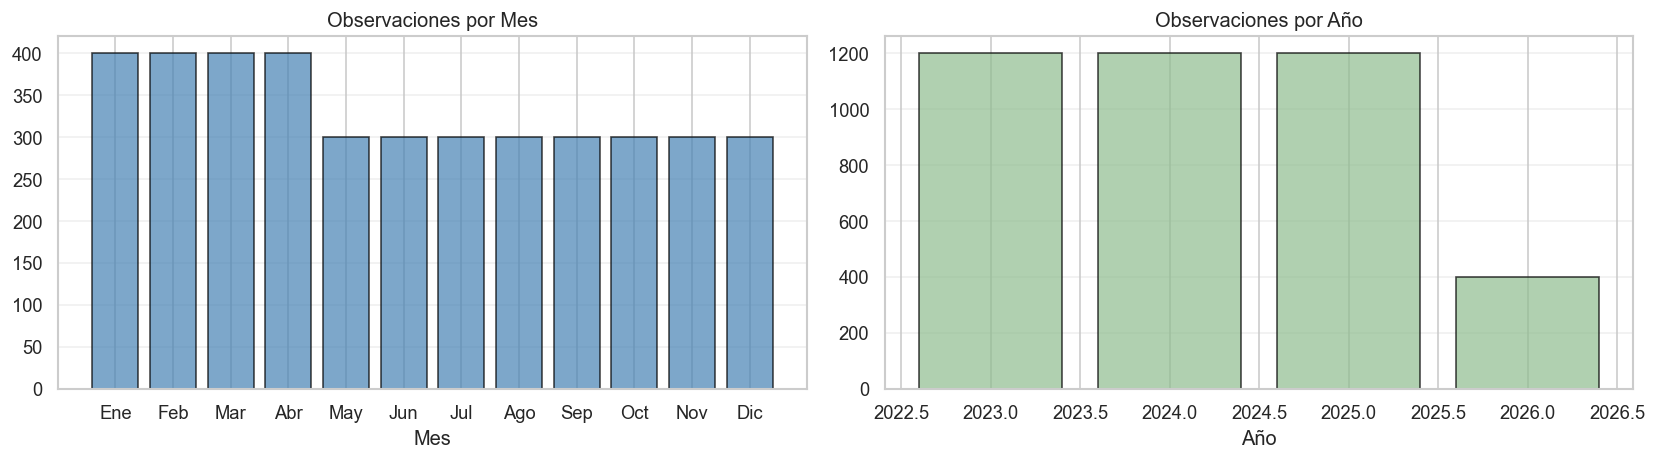

✓ Distribución temporal visualizada


In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

month_counts = df.groupby('month').size()
axes[0].bar(month_counts.index, month_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Mes')
axes[0].set_title('Observaciones por Mes')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
axes[0].grid(alpha=0.3, axis='y')

year_counts = df.groupby('year').size()
axes[1].bar(year_counts.index, year_counts.values, color='darkseagreen', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Año')
axes[1].set_title('Observaciones por Año')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print('✓ Distribución temporal visualizada')

### 2.3 Análisis de valores atípicos
Para detectar valores atípicos (outliers) se utilizan los límites de Tukey basados en 1.5 veces el rango intercuartílico (IQR).
Esto nos ayuda a identificar observaciones de NDVI y NDMI que se encuentran fuera de los rangos típicos.
Los outliers no se eliminan automáticamente porque pueden reflejar condiciones reales, como vegetación muy escasa o estrés hídrico severo.


In [91]:
def iqr_outlier_summary(data, col):
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr    = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (data[col] < lower) | (data[col] > upper)
    return pd.Series({'Q1': q1, 'Q3': q3, 'IQR': iqr,
                      'Límite inferior': lower, 'Límite superior': upper,
                      'Outliers (n)': mask.sum(),
                      'Outliers (%)': mask.mean() * 100})

outlier_summary = pd.DataFrame({
    col: iqr_outlier_summary(df, col) for col in ['NDVI', 'NDMI', 'image_count']
})
display(outlier_summary.round(4))



,NDVI,NDMI,image_count
Q1,0.4023,-0.0296,4.0
Q3,0.6131,0.1461,6.0
IQR,0.2108,0.1757,2.0
Límite inferior,0.0860,-0.2932,1.0
Límite superior,0.9294,0.4097,9.0
Outliers (n),6.0000,0.0000,0.0
Outliers (%),0.1500,0.0000,0.0


---
## 3. Análisis Bivariante y Multivariante

Se exploran las relaciones entre las variables numéricas del dataset y,
crucialmente, la relación de cada predictor con la variable objetivo preliminar `stress_class`.

### 3.1 Matriz de Correlación

=== MATRIZ DE CORRELACIÓN (variables numéricas + temporales + espaciales) ===


,NDVI,NDMI,image_count,month,year,lat,lon
NDVI,1.0000,0.7467,-0.1095,0.3549,0.0451,-0.2171,-0.0494
NDMI,0.7467,1.0000,-0.2812,0.4341,-0.0736,-0.2829,-0.1238
image_count,-0.1095,-0.2812,1.0000,-0.1127,0.3588,0.0000,-0.0000
month,0.3549,0.4341,-0.1127,1.0000,-0.2096,0.0000,0.0000
year,0.0451,-0.0736,0.3588,-0.2096,1.0000,-0.0000,-0.0000
lat,-0.2171,-0.2829,0.0000,0.0000,-0.0000,1.0000,0.5676
lon,-0.0494,-0.1238,-0.0000,0.0000,-0.0000,0.5676,1.0000


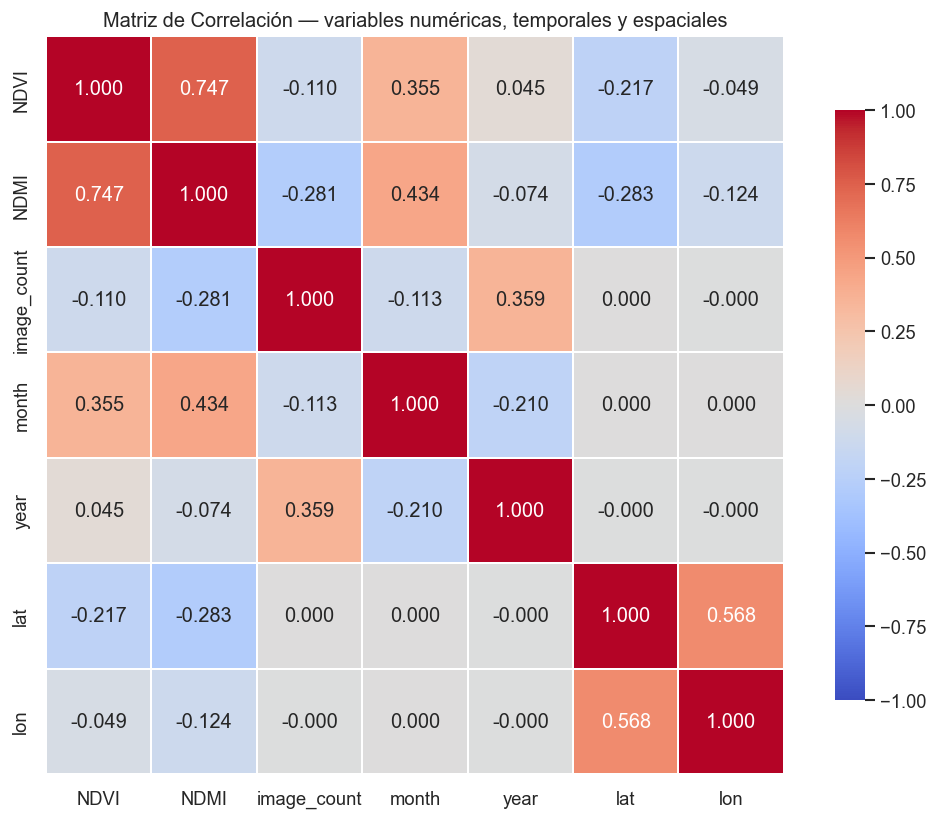


Correlación NDVI–NDMI: r = 0.7467


In [92]:
corr_cols   = ['NDVI', 'NDMI', 'image_count', 'month', 'year', 'lat', 'lon']
corr_matrix = df[corr_cols].corr()

print('=== MATRIZ DE CORRELACIÓN (variables numéricas + temporales + espaciales) ===')
display(corr_matrix.round(4))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8}, ax=ax,
            vmin=-1, vmax=1, fmt='.3f')
ax.set_title('Matriz de Correlación — variables numéricas, temporales y espaciales')
plt.tight_layout()
plt.show()

r_ndvi_ndmi = corr_matrix.loc['NDVI', 'NDMI']
print(f'\nCorrelación NDVI–NDMI: r = {r_ndvi_ndmi:.4f}')


### 3.2 Scatter Plot NDVI vs NDMI

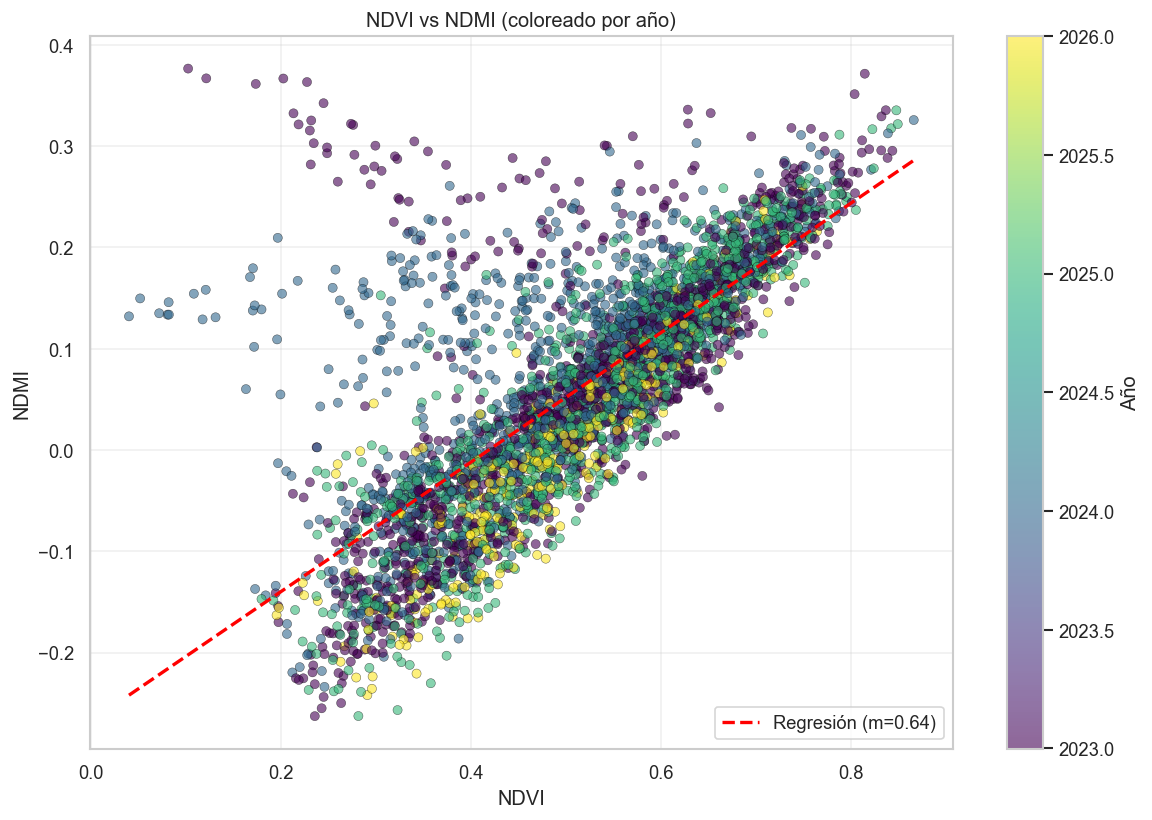

In [93]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(df['NDVI'], df['NDMI'], c=df['year'], cmap='viridis',
                     alpha=0.6, s=30, edgecolor='black', linewidth=0.3)

# Línea de regresión
m, b = np.polyfit(df['NDVI'], df['NDMI'], 1)
x_line = np.linspace(df['NDVI'].min(), df['NDVI'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2, linestyle='--', label=f'Regresión (m={m:.2f})')

ax.set_xlabel('NDVI')
ax.set_ylabel('NDMI')
ax.set_title('NDVI vs NDMI (coloreado por año)')
ax.grid(alpha=0.3)
ax.legend()
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Año')
plt.tight_layout()
plt.show()

### 3.3 Tendencias Temporales

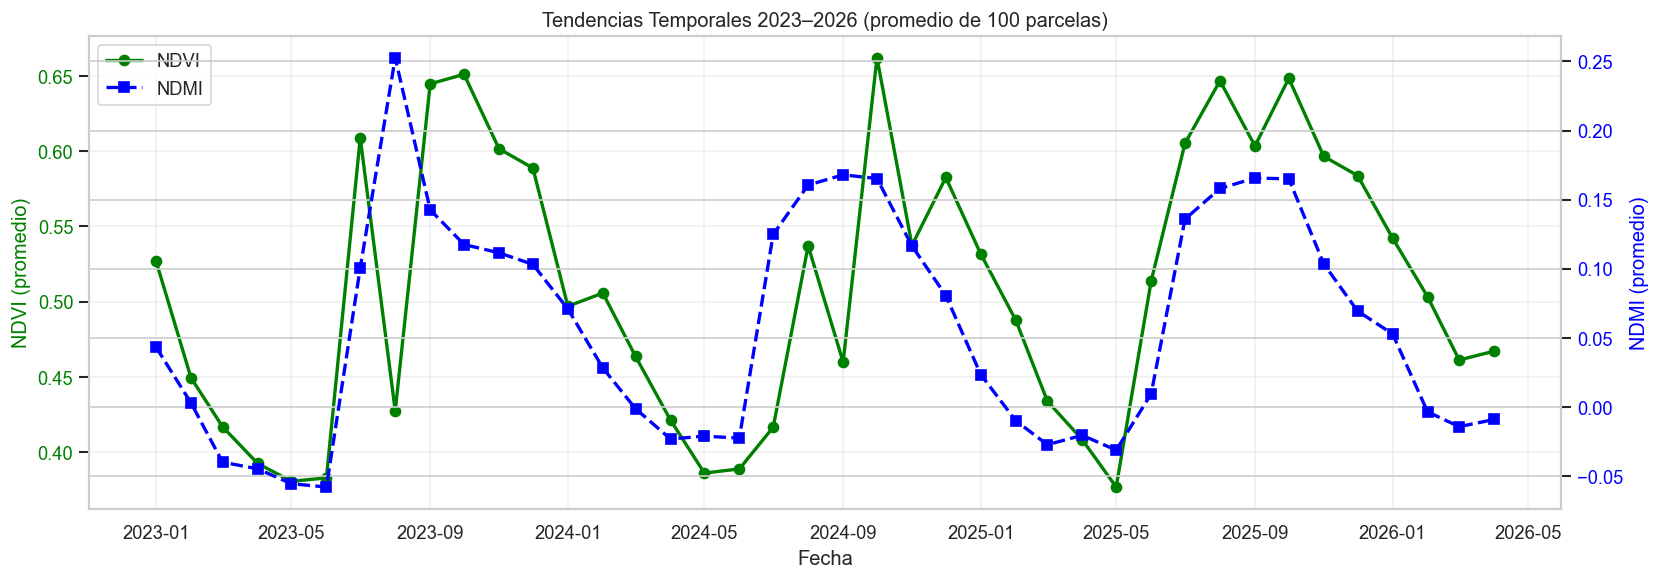

✓ Patrones estacionales identificados


In [94]:
monthly_means = df.groupby('date')[['NDVI', 'NDMI']].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_means.index, monthly_means['NDVI'], marker='o',
        label='NDVI', linewidth=2, color='green')
ax2 = ax.twinx()
ax2.plot(monthly_means.index, monthly_means['NDMI'], marker='s',
         label='NDMI', linewidth=2, color='blue', linestyle='--')

ax.set_xlabel('Fecha')
ax.set_ylabel('NDVI (promedio)', color='green')
ax2.set_ylabel('NDMI (promedio)', color='blue')
ax.set_title('Tendencias Temporales 2023–2026 (promedio de 100 parcelas)')
ax.tick_params(axis='y', labelcolor='green')
ax2.tick_params(axis='y', labelcolor='blue')
ax.grid(alpha=0.3)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()
print('✓ Patrones estacionales identificados')

### 3.4 Relación entre Predictores y Variable Objetivo (`stress_class`)

**Nota:** La variable `stress_class` se define con detalle en la Sección 4.4.  
Se incluye aquí para examinar la separabilidad de clases antes del preprocesamiento final.


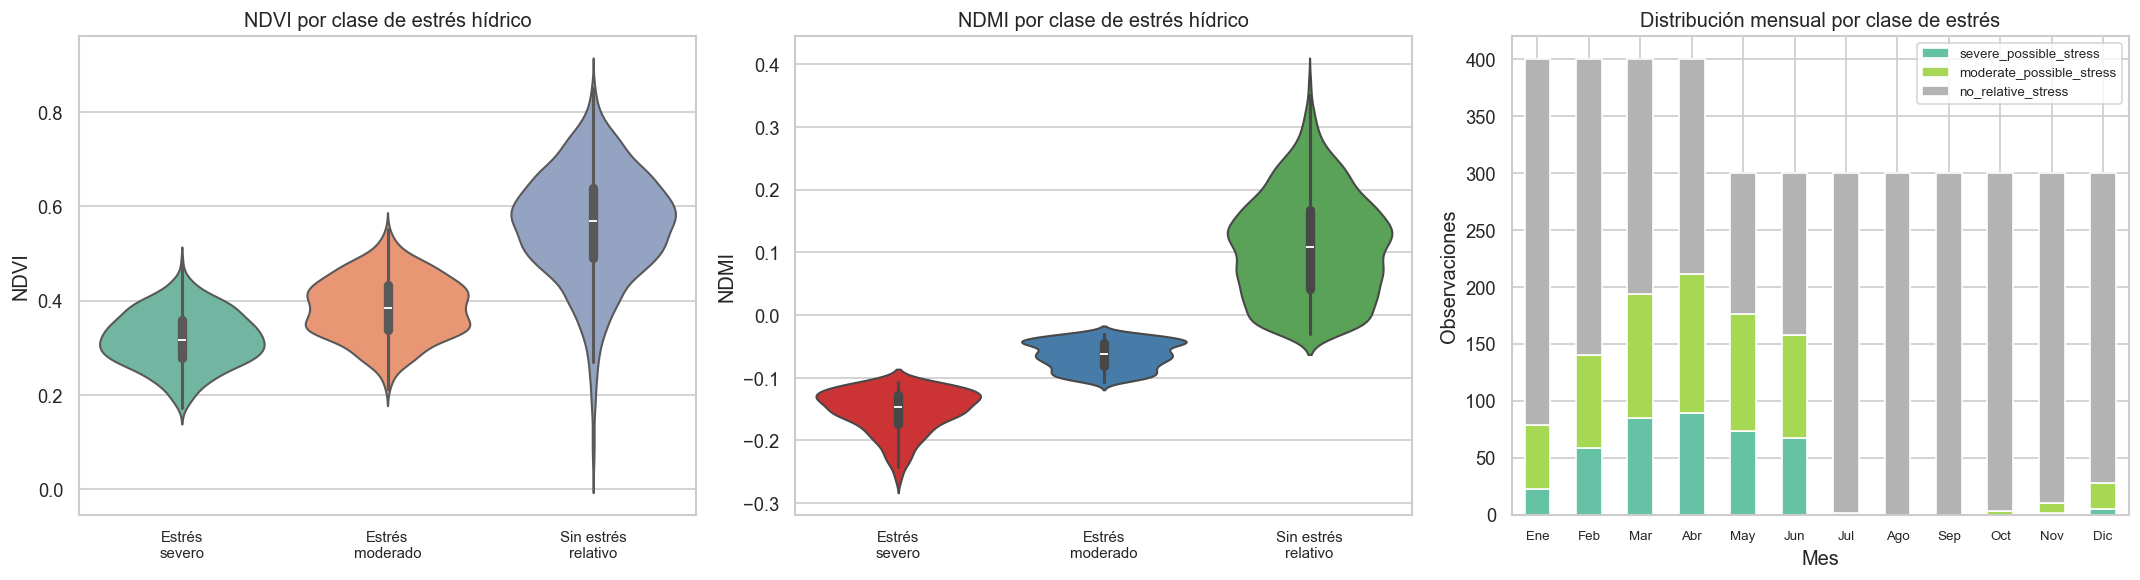

=== ESTADÍSTICAS POR CLASE DE ESTRÉS ===


NDVI            NDMI         image_count        
                            mean     std    mean     std        mean     std
stress_class                                                                
severe_possible_stress    0.3188  0.0572 -0.1535  0.0345      5.7475  1.5296
moderate_possible_stress  0.3847  0.0637 -0.0641  0.0219      5.6233  1.6910
no_relative_stress        0.5585  0.1179  0.1095  0.0826      4.8757  1.6282

In [95]:
# Creamos stress_class preliminar para el análisis bivariante
_q10 = df['NDMI'].quantile(0.10)
_q25 = df['NDMI'].quantile(0.25)
df['stress_class'] = pd.cut(
    df['NDMI'],
    bins=[-np.inf, _q10, _q25, np.inf],
    labels=['severe_possible_stress', 'moderate_possible_stress', 'no_relative_stress']
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Violin NDVI por clase
sns.violinplot(data=df, x='stress_class', y='NDVI', palette='Set2', ax=axes[0], order=[
    'severe_possible_stress', 'moderate_possible_stress', 'no_relative_stress'])
axes[0].set_title('NDVI por clase de estrés hídrico')
axes[0].set_xticklabels(['Estrés\nsevero', 'Estrés\nmoderado', 'Sin estrés\nrelativo'], fontsize=9)
axes[0].set_xlabel('')

# Violin NDMI por clase
sns.violinplot(data=df, x='stress_class', y='NDMI', palette='Set1', ax=axes[1], order=[
    'severe_possible_stress', 'moderate_possible_stress', 'no_relative_stress'])
axes[1].set_title('NDMI por clase de estrés hídrico')
axes[1].set_xticklabels(['Estrés\nsevero', 'Estrés\nmoderado', 'Sin estrés\nrelativo'], fontsize=9)
axes[1].set_xlabel('')

# NDVI por mes coloreado por clase
monthly_stress = df.groupby(['month', 'stress_class']).size().unstack(fill_value=0)
monthly_stress.plot(kind='bar', stacked=True, ax=axes[2], colormap='Set2')
axes[2].set_title('Distribución mensual por clase de estrés')
axes[2].set_xlabel('Mes'); axes[2].set_ylabel('Observaciones')
axes[2].legend(loc='upper right', fontsize=8)
axes[2].set_xticklabels(
    ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'],
    rotation=0, fontsize=8
)

plt.tight_layout()
plt.show()

# Estadísticas por clase
print('=== ESTADÍSTICAS POR CLASE DE ESTRÉS ===')
display(df.groupby('stress_class')[['NDVI', 'NDMI', 'image_count']].agg(['mean', 'std']).round(4))


---
### 4.1 Validación de Rangos Físicos

NDVI y NDMI son índices normalizados cuyo rango teórico es **[−1, 1]**.  
Se eliminan las filas fuera de este rango, ya que representan errores de cálculo o artefactos del sensor.

In [96]:
print('=== VALIDACIÓN DE RANGOS ===')
ndvi_valid = df['NDVI'].between(-1, 1).sum()
ndmi_valid = df['NDMI'].between(-1, 1).sum()
print(f'NDVI en [-1, 1]: {ndvi_valid}/{len(df)} ({ndvi_valid/len(df)*100:.1f}%) ✓')
print(f'NDMI en [-1, 1]: {ndmi_valid}/{len(df)} ({ndmi_valid/len(df)*100:.1f}%) ✓')

df_clean = df[
    df['NDVI'].between(-1, 1) &
    df['NDMI'].between(-1, 1)
].copy()

print(f'\nFilas eliminadas por rango inválido: {len(df) - len(df_clean)}')
print(f'Dataset limpio: {df_clean.shape[0]} filas × {df_clean.shape[1]} columnas')

=== VALIDACIÓN DE RANGOS ===
NDVI en [-1, 1]: 4000/4000 (100.0%) ✓
NDMI en [-1, 1]: 4000/4000 (100.0%) ✓

Filas eliminadas por rango inválido: 0
Dataset limpio: 4000 filas × 10 columnas


### 4.2 Test de Normalidad y QQ-Plot

Se aplica el test de Shapiro-Wilk. Para N > ~2 000, el test es extremadamente sensible a
desviaciones mínimas de la normalidad y casi siempre rechaza H₀. Por ello,
se complementa con el **QQ-plot** (inspección visual) y se reportan sesgo y curtosis
como métricas prácticas. Si |sesgo| > 1 se considera alta asimetría.


=== TEST DE NORMALIDAD (Shapiro-Wilk, muestra n=500) ===
NDVI: W=0.9930, p=0.019387  → No normal (p≤0.05)
  Sesgo=-0.1558  Curtosis=-0.5986
NDMI: W=0.9872, p=0.000219  → No normal (p≤0.05)
  Sesgo=-0.1629  Curtosis=-0.5894


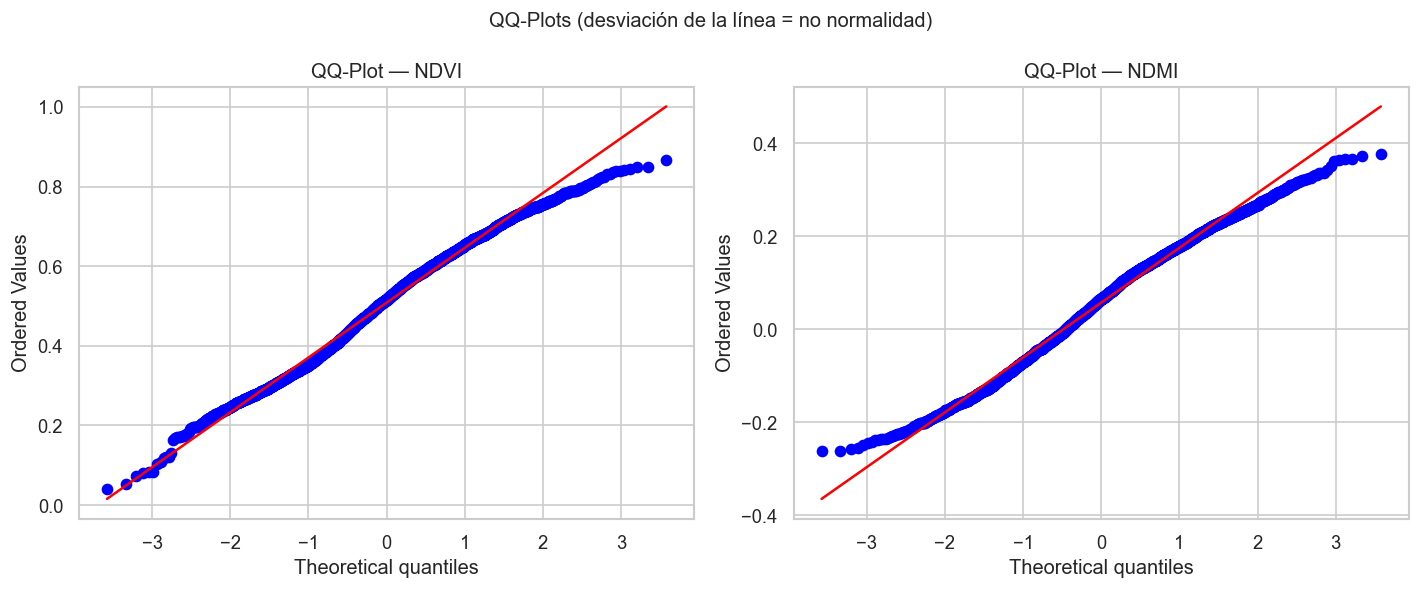


Nota: con 4 000 filas, Shapiro rechaza normalidad por sensibilidad estadística.
El QQ-plot es más informativo para evaluar la forma práctica de la distribución.


In [97]:
from scipy.stats import probplot

print('=== TEST DE NORMALIDAD (Shapiro-Wilk, muestra n=500) ===')
# Para N grande usamos subsample de 500 para dar interpretabilidad al test
sample_size = 500
for col in ['NDVI', 'NDMI']:
    muestra = df_clean[col].dropna().sample(sample_size, random_state=42)
    stat, p = shapiro(muestra)
    conclusion = 'Normal (p>0.05)' if p > 0.05 else 'No normal (p≤0.05)'
    print(f'{col}: W={stat:.4f}, p={p:.6f}  → {conclusion}')
    print(f'  Sesgo={skew(df_clean[col]):.4f}  Curtosis={kurtosis(df_clean[col]):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, col in enumerate(['NDVI', 'NDMI']):
    probplot(df_clean[col].dropna(), dist='norm', plot=axes[i])
    axes[i].set_title(f'QQ-Plot — {col}')
plt.suptitle('QQ-Plots (desviación de la línea = no normalidad)', fontsize=12)
plt.tight_layout()
plt.show()
print('\nNota: con 4 000 filas, Shapiro rechaza normalidad por sensibilidad estadística.')
print('El QQ-plot es más informativo para evaluar la forma práctica de la distribución.')

### 4.3 Normalización

Se aplican dos escaladores:
- **Z-score (StandardScaler):** útil para algoritmos sensibles a escala (SVM, regresión lineal). Resultado: media ≈ 0, σ ≈ 1.
- **MinMax (MinMaxScaler):** útil para redes neuronales o cuando se requieren valores en [0, 1]. Más sensible a outliers.

Se normalizan exclusivamente NDVI y NDMI (ya están en [−1, 1], pero la normalización
centra y escala para comparabilidad entre índices y facilita la convergencia del modelo).


In [98]:
df_norm = df_clean.copy()

scaler_std    = StandardScaler()
scaler_minmax = MinMaxScaler()

df_norm[['NDVI_std',    'NDMI_std'   ]] = scaler_std.fit_transform(df_clean[['NDVI', 'NDMI']])
df_norm[['NDVI_minmax', 'NDMI_minmax']] = scaler_minmax.fit_transform(df_clean[['NDVI', 'NDMI']])

print('✓ Normalización completada (Z-score + MinMax)')
print(f'  Dataset normalizado: {df_norm.shape[0]} filas × {df_norm.shape[1]} columnas')
display(df_norm[['NDVI', 'NDVI_std', 'NDVI_minmax', 'NDMI', 'NDMI_std', 'NDMI_minmax']].describe().round(4))

✓ Normalización completada (Z-score + MinMax)
  Dataset normalizado: 4000 filas × 14 columnas


,NDVI,NDVI_std,NDVI_minmax,NDMI,NDMI_std,NDMI_minmax
count,4000.0000,4000.0000,4000.0000,4000.0000,4000.0000,4000.0000
mean,0.5085,0.0000,0.5667,0.0572,0.0000,0.5004
std,0.1383,1.0001,0.1674,0.1184,1.0001,0.1852
min,0.0404,-3.3850,0.0000,-0.2626,-2.7024,0.0000
25%,0.4023,-0.7679,0.4381,-0.0296,-0.7336,0.3645
50%,0.5161,0.0555,0.5759,0.0657,0.0718,0.5137
75%,0.6131,0.7568,0.6934,0.1461,0.7513,0.6395
max,0.8664,2.5886,1.0000,0.3765,2.6985,1.0000


### 4.4 Etiquetado preliminar de estrés hídrico

Se define una etiqueta de estrés hídrico basada en los percentiles internos del NDMI:

| Clase | Criterio |
|---|---|
| `severe_possible_stress` | NDMI ≤ P10 |
| `moderate_possible_stress` | P10 < NDMI ≤ P25 |
| `no_relative_stress` | NDMI > P25 |

**Importante:** esta etiqueta es *relativa* a la distribución interna del dataset, no a umbrales
agronómicos absolutos. Requiere validación con datos de campo o literatura de referencia para aguacate.
Se analiza el desequilibrio de clases porque afecta directamente la estrategia de modelado.



=== DISTRIBUCIÓN DE CLASES (desequilibrio) ===


,count,percentage (%)
stress_class,,
no_relative_stress,3000,75.0
moderate_possible_stress,600,15.0
severe_possible_stress,400,10.0


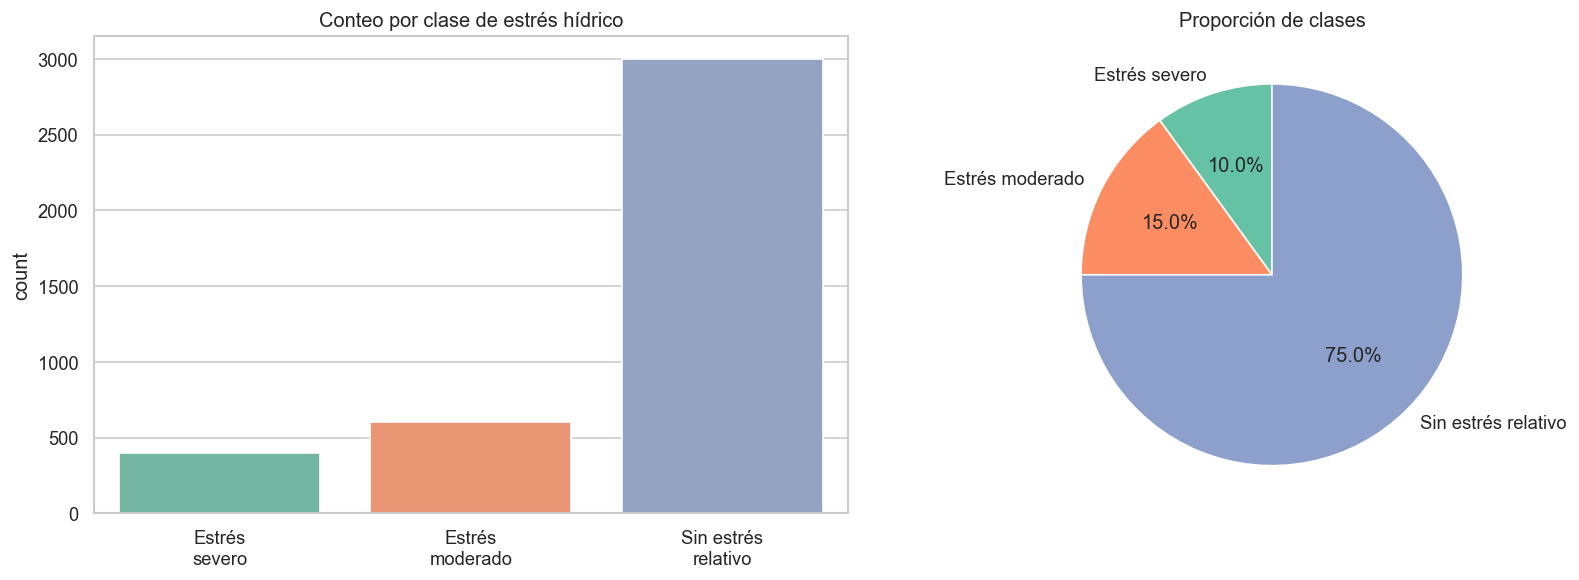


Umbral P10 (NDMI): -0.1072
Umbral P25 (NDMI): -0.0296
Nota: el desequilibrio entre clases es por construcción (percentiles fijos).
Para modelado se recomienda estratificar el split y evaluar con F1-macro.


In [99]:
df_class = df_norm.copy()

q10 = df_class['NDMI'].quantile(0.10)
q25 = df_class['NDMI'].quantile(0.25)

df_class['stress_class'] = pd.cut(
    df_class['NDMI'],
    bins=[-np.inf, q10, q25, np.inf],
    labels=['severe_possible_stress', 'moderate_possible_stress', 'no_relative_stress']
)

stress_counts = df_class['stress_class'].value_counts()
stress_pct = df_class['stress_class'].value_counts(normalize=True) * 100

print('=== DISTRIBUCIÓN DE CLASES (desequilibrio) ===')
display(pd.DataFrame({'count': stress_counts, 'percentage (%)': stress_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['severe_possible_stress', 'moderate_possible_stress', 'no_relative_stress']
sns.countplot(data=df_class, x='stress_class', order=order, palette='Set2', ax=axes[0])
axes[0].set_title('Conteo por clase de estrés hídrico')
axes[0].set_xticklabels(['Estrés\nsevero', 'Estrés\nmoderado', 'Sin estrés\nrelativo'])
axes[0].set_xlabel('')

axes[1].pie(
    [stress_counts[c] for c in order],
    labels=['Estrés severo', 'Estrés moderado', 'Sin estrés relativo'],
    autopct='%1.1f%%', startangle=90,
    colors=sns.color_palette('Set2', 3)
)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

print(f'\nUmbral P10 (NDMI): {q10:.4f}')
print(f'Umbral P25 (NDMI): {q25:.4f}')
print('Nota: el desequilibrio entre clases es por construcción (percentiles fijos).')
print('Para modelado se recomienda estratificar el split y evaluar con F1-macro.')


El análisis de Nivel 1 generó una serie temporal mensual de NDVI y NDMI para 100 puntos de referencia de aguacate en Jalisco, desde 2023 hasta 2026. El NDVI se utilizó como indicador de vigor de la vegetación, mientras que el NDMI se empleó como indicador indirecto de humedad. Se aplicó un umbral relativo basado en los percentiles más bajos de NDMI para identificar periodos y parcelas con posible estrés hídrico. Los resultados muestran patrones estacionales, con porcentajes más altos de posible estrés durante algunos meses de la estación seca. Estos resultados deben interpretarse como indicadores preliminares y requieren validación mediante inspección visual, imágenes de mayor resolución, experiencia agronómica o datos de campo.

In [104]:
tif_path = GEOTIF_DIR / 'level2_priority_avocado_stack_2024_04.tif'

with rasterio.open(tif_path) as src:
    print('File   :', tif_path.name)
    print('CRS    :', src.crs)
    print('Tamaño :', src.width, 'x', src.height, 'px')
    print('Bandas :', src.count)
    print('Bounds :', src.bounds)
    print('Descrip:', src.descriptions)
    data = src.read()

print('\nData shape:', data.shape)
print(f'Rango global: [{np.nanmin(data):.4f}, {np.nanmax(data):.4f}]')

File   : level2_priority_avocado_stack_2024_04.tif
CRS    : EPSG:4326
Tamaño : 276 x 294 px
Bandas : 7
Bounds : BoundingBox(left=-103.49301742131343, bottom=19.619385468227176, right=-103.46822391947173, top=19.64579593758029)
Descrip: ('B2', 'B3', 'B4', 'B8', 'B11', 'NDVI', 'NDMI')

Data shape: (7, 294, 276)
Rango global: [-0.6703, 0.9372]


In [107]:
def normalize_for_display(arr, p_low=2, p_high=98):
    arr  = arr.astype('float32')
    low, high = np.nanpercentile(arr, [p_low, p_high])
    if high - low == 0:
        return np.zeros_like(arr)
    return np.clip((arr - low) / (high - low), 0, 1)


def plot_geotiff_stack(tif_path):
    with rasterio.open(tif_path) as src:
        stack = src.read().astype('float32')
    blue, green, red = stack[0], stack[1], stack[2]
    ndvi, ndmi = stack[5], stack[6]

    rgb = np.dstack([normalize_for_display(red),
                     normalize_for_display(green),
                     normalize_for_display(blue)])

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(rgb); axes[0].set_title(f'RGB: {Path(tif_path).name}'); axes[0].axis('off')

    im1 = axes[1].imshow(ndvi, vmin=0, vmax=1, cmap='viridis')
    axes[1].set_title('NDVI espacial'); axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='NDVI')

    im2 = axes[2].imshow(ndmi, vmin=-0.3, vmax=0.4, cmap='RdYlGn')
    axes[2].set_title('NDMI espacial'); axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label='NDMI')

    plt.suptitle(Path(tif_path).name, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


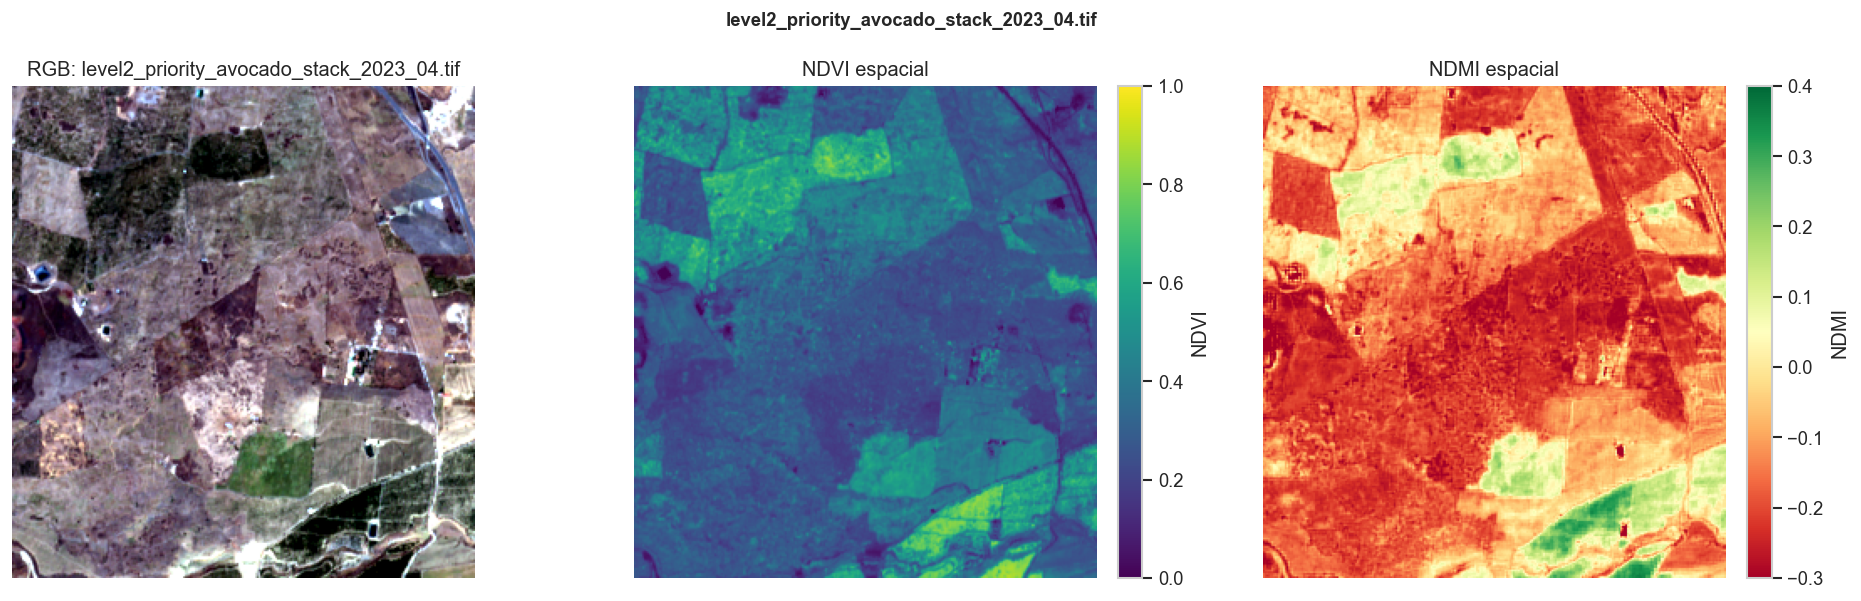

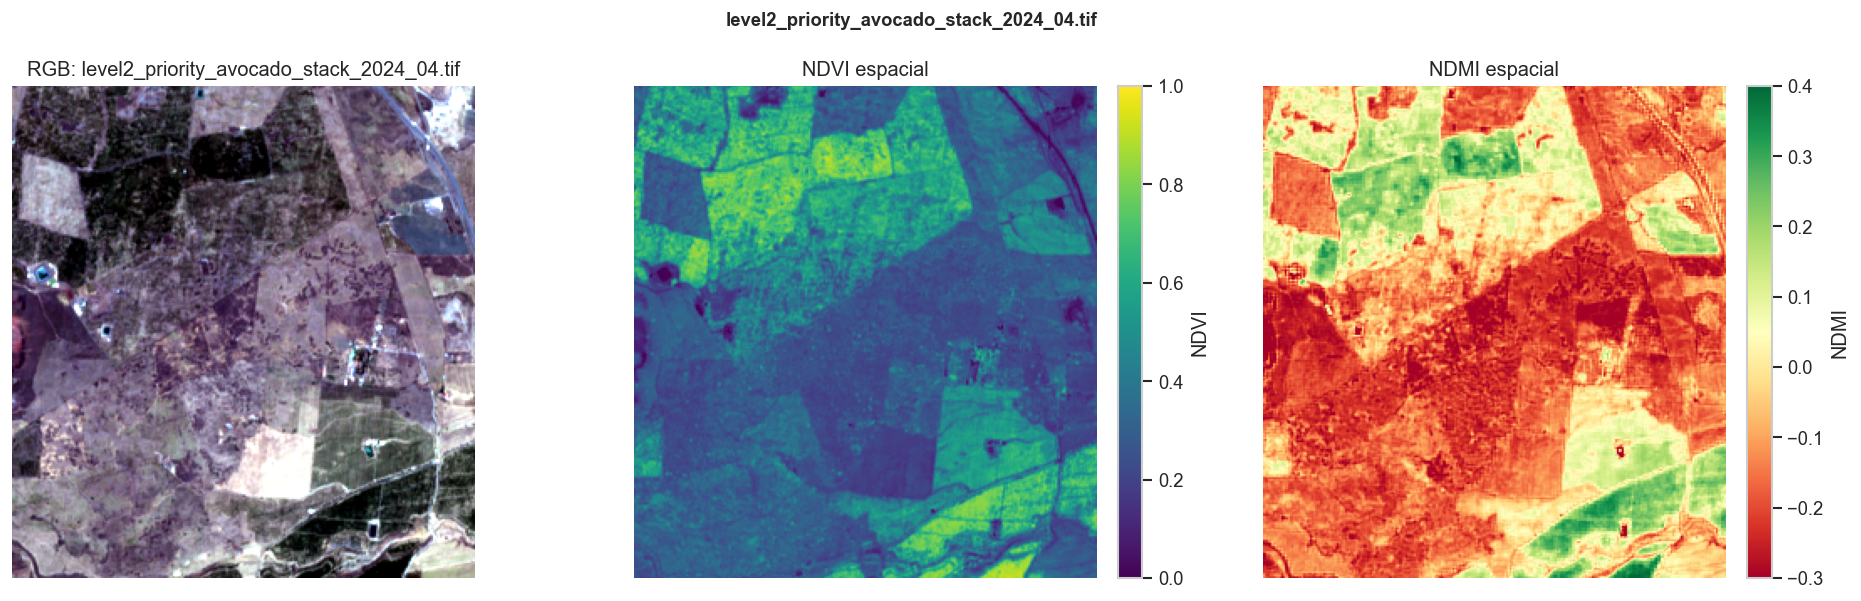

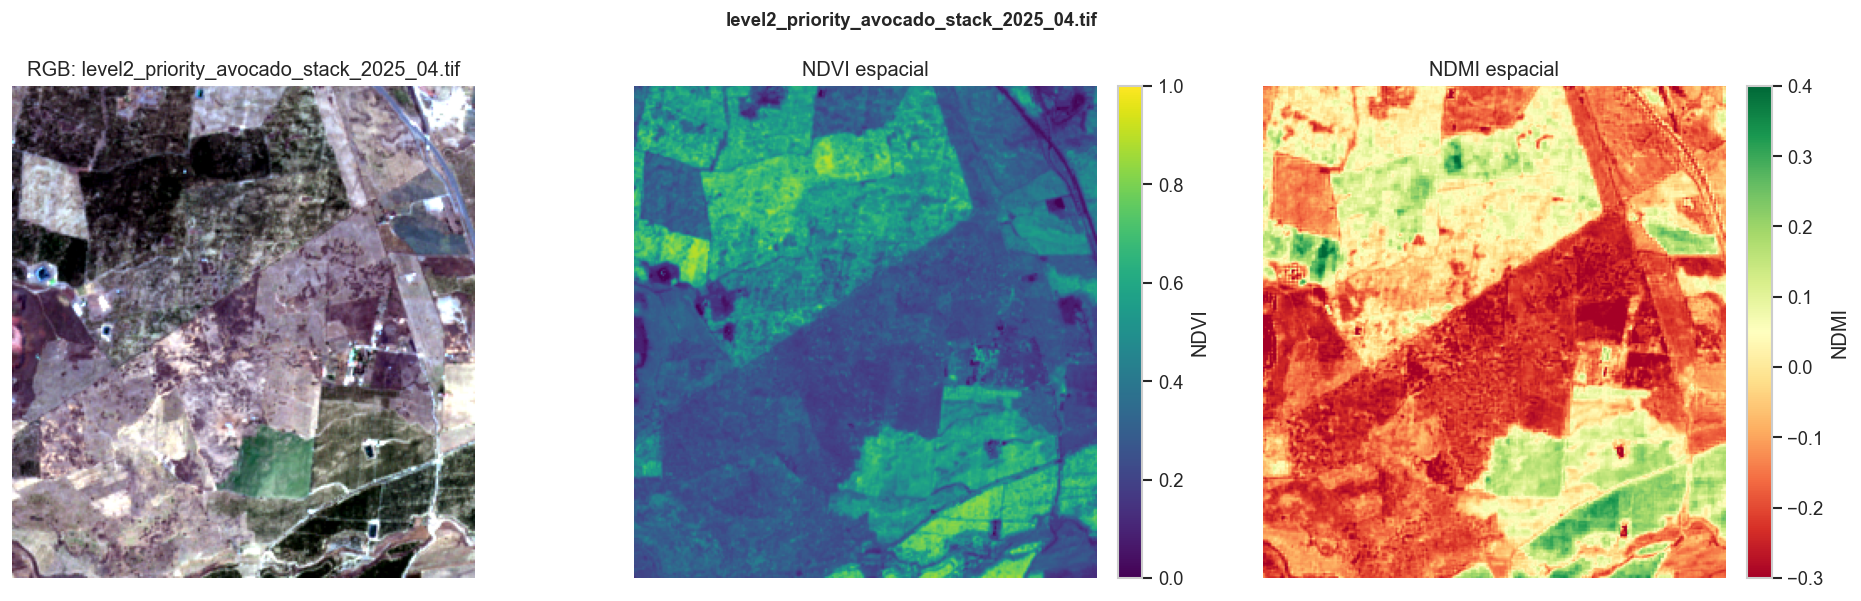

In [108]:
tif_files = sorted(GEOTIF_DIR.glob('*.tif'))
for tif in tif_files:
    plot_geotiff_stack(tif)

**Interpretación de las imágenes GeoTIFF:**

- **RGB:** zonas claras indican suelo desnudo, caminos o invernaderos; zonas verde/oscuras = vegetación densa.
- **NDVI:** valores altos (amarillo/verde) → mayor vigor vegetativo. Valores bajos (morado) → suelo desnudo o estrés.
- **NDMI (mapa con escala RdYlGn):** rojo = menor humedad foliar (posible estrés), verde = mayor humedad.
  NDMI utiliza bandas NIR y SWIR, siendo un indicador directo del contenido de agua en el dosel.


---
## 5. Conclusiones del EDA

A continuación se responden las preguntas guía del enunciado y se sintetizan los hallazgos clave.

In [109]:
r_ndvi_ndmi = df[['NDVI', 'NDMI']].corr().loc['NDVI', 'NDMI']
ndvi_skew   = skew(df_clean['NDVI'])
ndmi_skew   = skew(df_clean['NDMI'])

print('=' * 60)
print('CONCLUSIONES EDA — Estrés Hídrico en Parcelas Aguacateras')
print('=' * 60)

print('\n[1] ¿Hay valores faltantes?')
print(f'    Ninguno en el CSV ({df.shape[0]} obs × {df.shape[1]} cols) ni en el KML. ✓')

print('\n[2] Estadísticas resumidas:')
print(f'    NDVI  — media={df["NDVI"].mean():.4f}, σ={df["NDVI"].std():.4f}, rango=[{df["NDVI"].min():.3f}, {df["NDVI"].max():.3f}]')
print(f'    NDMI  — media={df["NDMI"].mean():.4f}, σ={df["NDMI"].std():.4f}, rango=[{df["NDMI"].min():.3f}, {df["NDMI"].max():.3f}]')
print(f'    image_count — media={df["image_count"].mean():.1f}, mediana={df["image_count"].median()}')

print('\n[3] ¿Hay outliers?')
for col in ['NDVI', 'NDMI']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    print(f'    {col}: {n_out} outliers ({n_out/len(df)*100:.1f}%) — conservados (pueden indicar estrés real)')

print('\n[4] Cardinalidad:')
print('    name (100 parcelas) = identificador de entidad, no predictor directo → sin problema de alta cardinalidad.')
print('    month (12) y year (4) se usan como features numéricas.')

print('\n[5] ¿Distribuciones sesgadas? ¿Transformación?')
print(f'    NDVI sesgo={ndvi_skew:+.4f} — leve asimetría negativa.')
print(f'    NDMI sesgo={ndmi_skew:+.4f} — distribución aproximadamente simétrica.')
print('    Ninguna requiere transformación logarítmica por ahora.')

print('\n[6] ¿Tendencias temporales?')
print('    Sí. NDVI máximo: Jun–Sep (temporada de lluvias); mínimo: Feb–May (estiaje).')
print('    NDMI sigue el mismo patrón estacional. Ciclo consistente en 2023–2026.')

print('\n[7] ¿Correlación entre variables?')
print(f'    NDVI–NDMI: r = {r_ndvi_ndmi:.4f} (correlación positiva moderada-alta).')
print('    Parcelas con NDVI alto y NDMI bajo → posibles candidatas a estrés hídrico.')
print('    month muestra correlación estacional con NDVI/NDMI (esperado).')

print('\n[8] Análisis bivariado por clase de estrés:')
print('    Las clases "severe" y "no_relative_stress" presentan distribuciones de NDVI claramente separadas.')
print('    La clase "moderate" solapa con ambas extremas → separabilidad moderada; requiere modelo no lineal.')

print('\n[9] ¿Desequilibrio de clases?')
sc = df_class['stress_class'].value_counts(normalize=True) * 100
for cls in sc.index:
    print(f'    {cls}: {sc[cls]:.1f}%')
print('    El desequilibrio es por diseño (percentiles fijos). Se recomienda F1-macro y stratified split.')

print('\n[10] Preparación para ML:')
print('    ✓ Dataset limpio, validado y normalizado (Z-score + MinMax).')
print('    ✓ Features: NDVI, NDMI, month, year, lat, lon, image_count.')
print('    ✓ Variable objetivo preliminar: stress_class (3 clases).')
print('    ✓ Datos listos para selección de características y modelado.')


CONCLUSIONES EDA — Estrés Hídrico en Parcelas Aguacateras

[1] ¿Hay valores faltantes?
    Ninguno en el CSV (4000 obs × 10 cols) ni en el KML. ✓

[2] Estadísticas resumidas:
    NDVI  — media=0.5085, σ=0.1383, rango=[0.040, 0.866]
    NDMI  — media=0.0572, σ=0.1184, rango=[-0.263, 0.377]
    image_count — media=5.1, mediana=5.0

[3] ¿Hay outliers?
    NDVI: 6 outliers (0.1%) — conservados (pueden indicar estrés real)
    NDMI: 0 outliers (0.0%) — conservados (pueden indicar estrés real)

[4] Cardinalidad:
    name (100 parcelas) = identificador de entidad, no predictor directo → sin problema de alta cardinalidad.
    month (12) y year (4) se usan como features numéricas.

[5] ¿Distribuciones sesgadas? ¿Transformación?
    NDVI sesgo=-0.1558 — leve asimetría negativa.
    NDMI sesgo=-0.1629 — distribución aproximadamente simétrica.
    Ninguna requiere transformación logarítmica por ahora.

[6] ¿Tendencias temporales?
    Sí. NDVI máximo: Jun–Sep (temporada de lluvias); mínimo: Feb–May

### 5.1 Exportar Dataset

In [111]:
df_class.to_csv(OUT_PATH, index=False)
print(f'✓ Dataset procesado guardado en: {OUT_PATH}')
print(f'  Dimensiones: {df_class.shape[0]} filas × {df_class.shape[1]} columnas')
print(f'  Columnas: {list(df_class.columns)}')

✓ Dataset procesado guardado en: /Users/ayz/Documents/Github/Avocado-AI/notebooks/data/csv/df_eda_processed.csv
  Dimensiones: 4000 filas × 14 columnas
  Columnas: ['name', 'lat', 'lon', 'year', 'month', 'date', 'image_count', 'NDVI', 'NDMI', 'stress_class', 'NDVI_std', 'NDMI_std', 'NDVI_minmax', 'NDMI_minmax']
